# PtychoPINN Batch Size Energy Results

This notebook reads the `bs*_power.csv` traces under `power_experiments`, integrates `GPU0_Power(W)` over time, and plots the energy consumption by accelerator, dataset, and inference batch size. It intentionally uses only GPU 0 because the current experiments are single-GPU runs.

In [1]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import pandas as pd

try:
    from IPython.display import display
except ImportError:
    display = print

cwd = Path.cwd().resolve()
search_roots = [cwd, *cwd.parents]
power_candidates = []
for root in search_roots:
    power_candidates.extend([
        root / "PtychoPINN" / "power_experiments",
    ])

power_root = next((path for path in power_candidates if path.exists()), None)
if power_root is None:
    raise FileNotFoundError(f"Could not find power_experiments from {cwd}")

plot_dir = power_root.parent / "plot"

print(f"Reading power results from: {power_root}")
print(f"Using plot directory: {plot_dir}")

Reading power results from: /home/zhong.zheng/PtychoPINN/power_experiments
Using plot directory: /home/zhong.zheng/PtychoPINN/plot


In [2]:
def integrate_power_trace(csv_path: Path) -> dict:
    """Return integrated energy in joules for one power trace."""
    trace = pd.read_csv(csv_path)
    power_col = "GPU0_Power(W)"
    if "Time(S)" not in trace.columns or power_col not in trace.columns:
        raise ValueError(f"Unexpected power CSV schema: {csv_path}")

    trace = trace[["Time(S)", power_col]].dropna()
    trace = trace.sort_values("Time(S)").drop_duplicates("Time(S)")
    trace["gpu0_power_w"] = trace[power_col]

    duration_s = trace["Time(S)"].iloc[-1] - trace["Time(S)"].iloc[0]
    energy_j = 0.0
    times = trace["Time(S)"].to_numpy()
    powers = trace["gpu0_power_w"].to_numpy()
    for t0, t1, p0, p1 in zip(times, times[1:], powers, powers[1:]):
        dt = t1 - t0
        if dt > 0:
            energy_j += dt * (p0 + p1) / 2.0

    return {
        "energy_j": energy_j,
        "duration_s": duration_s,
        "avg_gpu0_power_w": trace["gpu0_power_w"].mean(),
        "samples": len(trace),
        "power_column": power_col,
    }


rows = []
known_datasets = {"TP1", "TP2", "IC1", "IC2", "NCM", "FLY1", "LFP", "W", "LCLS"}

for csv_path in sorted(power_root.glob("**/bs*_power.csv")):
    match = re.fullmatch(r"bs(\d+)_power\.csv", csv_path.name)
    if not match:
        continue

    relative_parts = csv_path.relative_to(power_root).parts
    accelerator = relative_parts[0]
    dataset = next((part for part in relative_parts[1:-1] if part in known_datasets), None)
    if dataset is None:
        continue
    batch_size = int(match.group(1))
    metrics = integrate_power_trace(csv_path)

    rows.append({
        "accelerator": accelerator,
        "dataset": dataset,
        "batch_size": batch_size,
        "csv_path": str(csv_path),
        **metrics,
    })

results = pd.DataFrame(rows).sort_values(["accelerator", "dataset", "batch_size"])
results["batch_size"] = results["batch_size"].astype(int)
results["energy_kj"] = results["energy_j"] / 1000.0
results.head()

,accelerator,dataset,batch_size,csv_path,energy_j,duration_s,avg_gpu0_power_w,samples,power_column,energy_kj
3,A100,FLY1,32,/home/zhong.zheng/PtychoPINN/power_experiments...,922.20545,25.02,36.856190,126,GPU0_Power(W),0.922205
5,A100,FLY1,64,/home/zhong.zheng/PtychoPINN/power_experiments...,715.26165,18.82,37.975158,95,GPU0_Power(W),0.715262
1,A100,FLY1,128,/home/zhong.zheng/PtychoPINN/power_experiments...,699.61505,15.21,45.859870,77,GPU0_Power(W),0.699615
2,A100,FLY1,256,/home/zhong.zheng/PtychoPINN/power_experiments...,641.23495,14.22,44.937222,72,GPU0_Power(W),0.641235
4,A100,FLY1,512,/home/zhong.zheng/PtychoPINN/power_experiments...,594.40240,13.61,43.553623,69,GPU0_Power(W),0.594402


In [5]:
plt.style.use("seaborn-v0_8-whitegrid")

batch_sizes = [32, 64, 128, 256, 512, 1024]
machines_to_plot = ["A100", "H100", "H200","B200", "MI300A", "MI300X","Max"]  
# machines_to_plot = ["A100", "H100", "H200","MI300X","MI300A","Max"]  

plot_results = results[results["batch_size"].isin(batch_sizes)].copy()
plot_results = plot_results.loc[
    plot_results.groupby(["accelerator", "dataset", "batch_size"])["energy_j"].idxmin()
].copy()

available_machines = sorted(plot_results["accelerator"].unique())
if machines_to_plot is None:
    accelerators = available_machines
else:
    missing_machines = sorted(set(machines_to_plot) - set(available_machines))
    if missing_machines:
        raise ValueError(f"Requested machines not found: {missing_machines}. Available: {available_machines}")
    accelerators = list(machines_to_plot)
    plot_results = plot_results[plot_results["accelerator"].isin(accelerators)].copy()

if plot_results.empty:
    raise ValueError("No rows left to plot after applying batch size and machine filters.")

plot_results["normalized_time"] = plot_results["duration_s"] / plot_results.groupby("dataset")["duration_s"].transform("max")
plot_results["normalized_energy"] = plot_results["energy_kj"] / plot_results.groupby("dataset")["energy_kj"].transform("max")

datasets = sorted(plot_results["dataset"].unique())
colors = plt.cm.tab10.colors
batch_color_map = {batch_size: colors[i % len(colors)] for i, batch_size in enumerate(batch_sizes)}

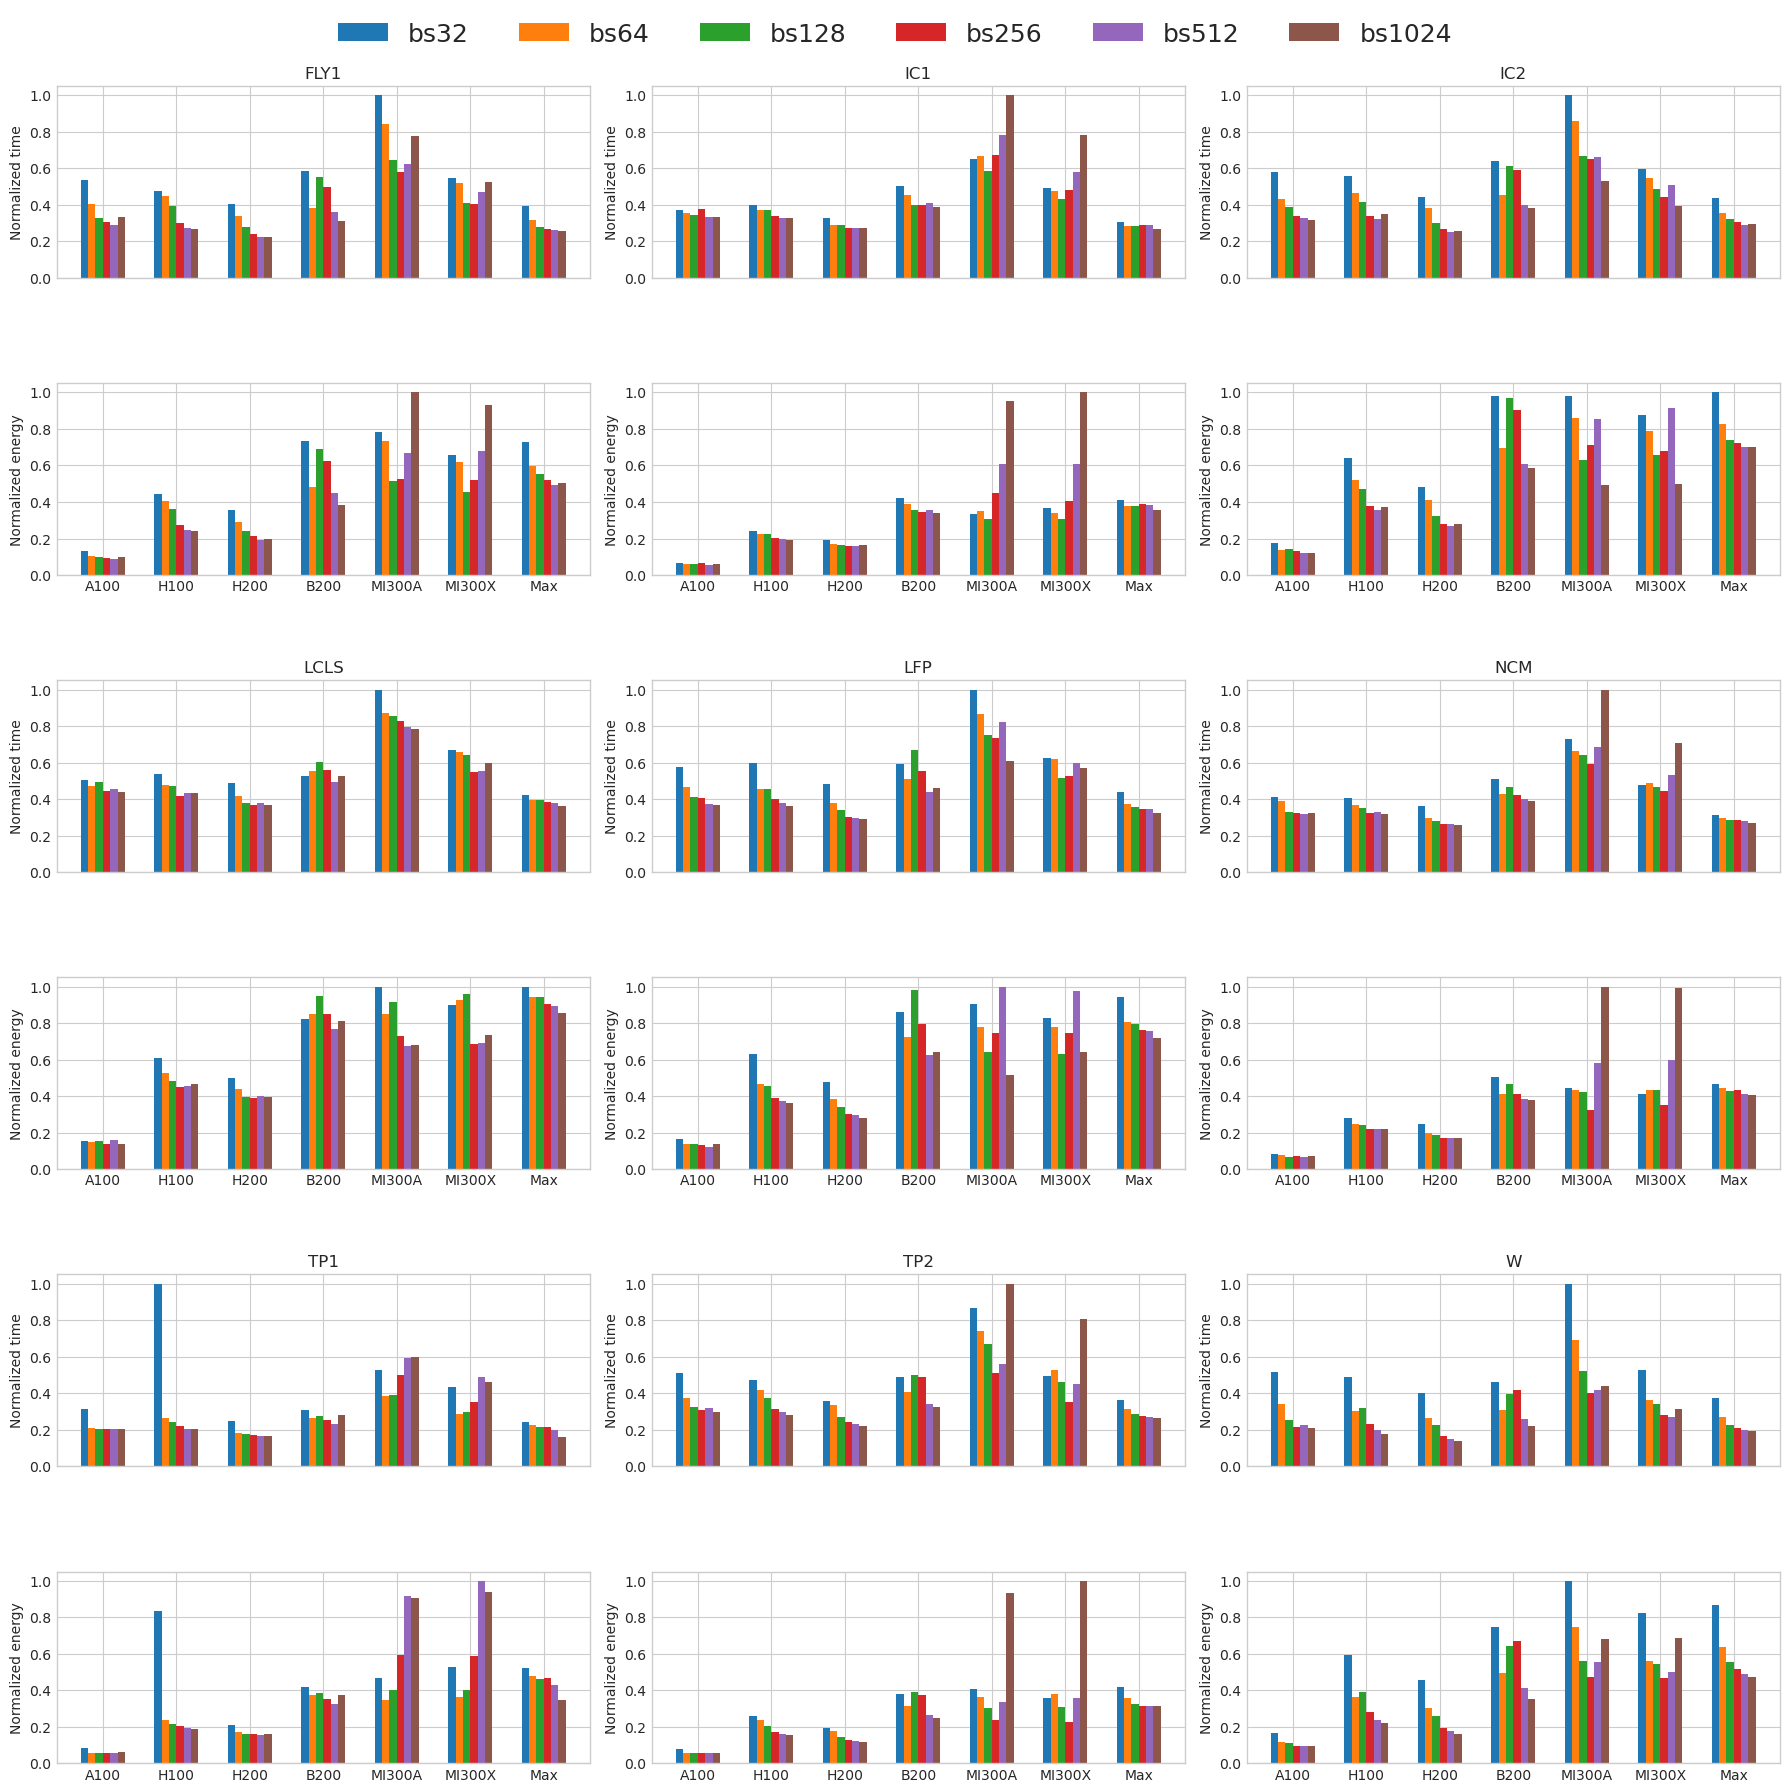

In [6]:
ncols = 3
dataset_rows = (len(datasets) + ncols - 1) // ncols
fig, axes = plt.subplots(dataset_rows * 2, ncols, figsize=(18, 6.0 * dataset_rows), sharex=False, sharey=False)
axes = axes.reshape(dataset_rows * 2, ncols)
x = list(range(len(accelerators)))
bar_width = min(0.1, 0.8 / len(batch_sizes))

def plot_grouped_bars(ax, metric_lookup, ylabel):
    for batch_index, batch_size in enumerate(batch_sizes):
        offset = (batch_index - (len(batch_sizes) - 1) / 2) * bar_width
        heights = [metric_lookup.get((accelerator, batch_size), float("nan")) for accelerator in accelerators]
        ax.bar(
            [position + offset for position in x],
            heights,
            width=bar_width,
            label=f"bs{batch_size}",
            color=batch_color_map[batch_size],
        )
    ax.set_ylabel(ylabel)


for dataset_index, dataset in enumerate(datasets):
    row = (dataset_index // ncols) * 2
    col = dataset_index % ncols
    time_ax = axes[row, col]
    energy_ax = axes[row + 1, col]

    dataset_results = plot_results[plot_results["dataset"] == dataset]
    energy_lookup = dataset_results.set_index(["accelerator", "batch_size"])["normalized_energy"]
    time_lookup = dataset_results.set_index(["accelerator", "batch_size"])["normalized_time"]

    plot_grouped_bars(time_ax, time_lookup, "Normalized time")
    plot_grouped_bars(energy_ax, energy_lookup, "Normalized energy")

    time_ax.set_title(dataset)
    time_ax.set_xticks(x)
    time_ax.set_xticklabels([])
    energy_ax.set_xticks(x)
    energy_ax.set_xticklabels(accelerators)
    # energy_ax.set_xlabel("Machine")

for dataset_index in range(len(datasets), dataset_rows * ncols):
    row = (dataset_index // ncols) * 2
    col = dataset_index % ncols
    axes[row, col].axis("off")
    axes[row + 1, col].axis("off")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=len(batch_sizes), frameon=False, fontsize=18)
# fig.suptitle("PtychoPINN Time and Energy by Machine and Batch Size", y=1.01, fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.97])
fig.subplots_adjust(hspace=0.55)

plt.show()

# Resolution